#Analyse und Prognose der Windgeschwindigkeit in Würzburg

##- Datenimport

Hier werden auch die Daten meinen Kommilitonen importiert

In [1]:
# DATEN LADEN – DWD Würzburg
# Zeitreihen: Wind (Kenia) | Luftdruck (Jonas) | Temperatur (Clara)
# Quelle: DWD CDC Open Data Server
# Cutoff: 01.01.2026


import io
import re
import zipfile
import requests
import pandas as pd
from datetime import date

# ── Konfiguration ─────────────────────────────────────────────
STATION_ID = "05705"
BASE_URL   = "https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/"
CUTOFF     = date(2026, 1, 1)   # Festes Stoppdatum: 01.05.2026


# ── Hilfsfunktionen ───────────────────────────────────────────
def download_zip(url: str) -> zipfile.ZipFile:
    """Lädt eine ZIP-Datei von der DWD-URL und gibt sie als ZipFile zurück."""
    print(f"  → Lade: {url}")
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return zipfile.ZipFile(io.BytesIO(r.content))


def read_zip(zf: zipfile.ZipFile) -> pd.DataFrame:
    """Liest die Datendatei (produkt_*.txt) aus einem DWD-ZIP-Archiv."""
    data_file = [f for f in zf.namelist() if f.startswith("produkt_")][0]
    with zf.open(data_file) as f:
        return pd.read_csv(f, sep=";", encoding="latin-1")


def load_raw_data(station_id: str, base_url: str, cutoff: date) -> pd.DataFrame:
    """
    Lädt und kombiniert historische und aktuelle DWD-Daten für eine Station.
    Bereinigt Spaltennamen, setzt Datumsindex, ersetzt Fehlerwerte und
    schneidet am Cutoff-Datum ab.
    """
    print(f"\n{'='*55}")
    print(f"  Station: {station_id} | Cutoff: {cutoff}")
    print(f"{'='*55}")

    # Recent herunterladen
    print("\n[1/2] Aktuelle Daten:")
    zf_recent  = download_zip(f"{base_url}recent/tageswerte_KL_{station_id}_akt.zip")
    df_recent  = read_zip(zf_recent)

    # Historical herunterladen
    print("\n[2/2] Historische Daten:")
    base_hist  = base_url + "historical/"
    r          = requests.get(base_hist, timeout=30)
    pattern    = rf"tageswerte_KL_{station_id}_\d{{8}}_\d{{8}}_hist\.zip"
    filename   = re.findall(pattern, r.text)[0]
    zf_hist    = download_zip(base_hist + filename)
    df_hist    = read_zip(zf_hist)

    # Zusammenführen
    df = pd.concat([df_hist, df_recent], ignore_index=True)

    # Bereinigen
    df.columns     = df.columns.str.strip()
    df["MESS_DATUM"] = pd.to_datetime(df["MESS_DATUM"], format="%Y%m%d")
    df             = df.set_index("MESS_DATUM").sort_index()
    df             = df.replace(-999.0, float("nan"))
    df             = df.replace(-999,   float("nan"))
    df             = df[df.index.date <= cutoff]
    df             = df[~df.index.duplicated(keep="last")]

    return df


def summarize(name: str, df: pd.DataFrame):
    """Gibt eine kurze Zusammenfassung eines DataFrames aus."""
    print(f"\n  {name}:")
    print(f"    Zeitraum:       {df.index[0].date()} bis {df.index[-1].date()}")
    print(f"    Beobachtungen:  {len(df)}")
    print(f"    Fehlende Werte: {df.isna().sum().to_dict()}")


# ── Daten laden ───────────────────────────────────────────────
df_all_raw = load_raw_data(STATION_ID, BASE_URL, CUTOFF)


# ── Drei separate Zeitreihen extrahieren ──────────────────────
# Kenia – Wind
df_wind            = df_all_raw[["FM", "FX"]].copy()
df_wind.columns    = ["windgeschwindigkeit_ms", "windspitze_ms"]
df_wind            = df_wind.dropna(how="all")

# Jonas – Luftdruck
df_druck           = df_all_raw[["PM"]].copy()
df_druck.columns   = ["luftdruck_hpa"]
df_druck           = df_druck.dropna()

# Clara – Temperatur
df_temp            = df_all_raw[["TMK", "TXK", "TNK"]].copy()
df_temp.columns    = ["temperatur_mittel_c", "temperatur_max_c", "temperatur_min_c"]
df_temp            = df_temp.dropna(how="all")


# ── Zusammenfassung ───────────────────────────────────────────
print(f"\n{'='*55}")
print("  ÜBERSICHT DER ZEITREIHEN")
print(f"{'='*55}")
summarize("Wind          (Kenia)", df_wind)
summarize("Luftdruck     (Jonas)", df_druck)
summarize("Temperatur    (Clara)", df_temp)
print(f"\n{'='*55}")
print("  Daten erfolgreich geladen ✅")
print(f"{'='*55}\n")


  Station: 05705 | Cutoff: 2026-01-01

[1/2] Aktuelle Daten:
  → Lade: https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/recent/tageswerte_KL_05705_akt.zip

[2/2] Historische Daten:
  → Lade: https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/historical/tageswerte_KL_05705_19470101_20241231_hist.zip

  ÜBERSICHT DER ZEITREIHEN

  Wind          (Kenia):
    Zeitraum:       1966-01-01 bis 2026-01-01
    Beobachtungen:  21799
    Fehlende Werte: {'windgeschwindigkeit_ms': 9, 'windspitze_ms': 1483}

  Luftdruck     (Jonas):
    Zeitraum:       1947-01-01 bis 2026-01-01
    Beobachtungen:  28848
    Fehlende Werte: {'luftdruck_hpa': 0}

  Temperatur    (Clara):
    Zeitraum:       1947-01-01 bis 2026-01-01
    Beobachtungen:  28856
    Fehlende Werte: {'temperatur_mittel_c': 0, 'temperatur_max_c': 90, 'temperatur_min_c': 90}

  Daten erfolgreich geladen ✅



## - Datenbereinigung

In [2]:
import pandas as pd
import numpy as np

# Nur FM (windgeschwindigkeit9 df_wind extrahieren
wind = df_wind["windgeschwindigkeit_ms"].copy()

print("Vor der Bereinigung")
print(f"Zeitraum:          {wind.index[0].date()} bis {wind.index[-1].date()}")
print(f"Anzahl Werte:      {len(wind)}")
print(f"Fehlende Werte:    {wind.isna().sum()}")
print(f"Negative Werte:    {(wind < 0).sum()}")
print(f"Nullwerte:         {(wind == 0).sum()}")
print(f"\nErste 5 Zeilen:\n{wind.head()}")

# ── Fehlende Werte behandeln ─────────────────────────────────
# Methode: lineare Interpolation (da nur 12 fehlende Tage)
wind_clean = wind.interpolate(method="linear")

# ── Sicherstellen dass kein negativer Wert existiert ─────────
wind_clean = wind_clean.clip(lower=0)

# ── Vollständigen Datumsindex sicherstellen ──────────────────
# (falls einzelne Tage komplett fehlen)
full_index = pd.date_range(
    start=wind_clean.index[0],
    end=wind_clean.index[-1],
    freq="D"
)
wind_clean = wind_clean.reindex(full_index)
wind_clean = wind_clean.interpolate(method="linear")

print("\n Nach der Bereinigung")
print(f"Zeitraum:          {wind_clean.index[0].date()} bis {wind_clean.index[-1].date()}")
print(f"Anzahl Werte:      {len(wind_clean)}")
print(f"Fehlende Werte:    {wind_clean.isna().sum()}")
print(f"Negative Werte:    {(wind_clean < 0).sum()}")
print(f"\nErste 5 Zeilen:\n{wind_clean.head()}")

Vor der Bereinigung
Zeitraum:          1966-01-01 bis 2026-01-01
Anzahl Werte:      21799
Fehlende Werte:    9
Negative Werte:    0
Nullwerte:         6

Erste 5 Zeilen:
MESS_DATUM
1966-01-01     8.5
1966-01-02     9.0
1966-01-03    11.1
1966-01-04     6.9
1966-01-05     1.4
Name: windgeschwindigkeit_ms, dtype: float64

 Nach der Bereinigung
Zeitraum:          1966-01-01 bis 2026-01-01
Anzahl Werte:      21916
Fehlende Werte:    0
Negative Werte:    0

Erste 5 Zeilen:
1966-01-01     8.5
1966-01-02     9.0
1966-01-03    11.1
1966-01-04     6.9
1966-01-05     1.4
Freq: D, Name: windgeschwindigkeit_ms, dtype: float64


## - Deskriptive Analyse  – Wind Geschwindigkeit (FM)

In [3]:
import pandas as pd
import numpy as np

# ── Grundlegende Statistiken ─────────────────────────────────
print("Deskriptive Statistiken\n")

stats = pd.DataFrame({
    "Kennzahl": [
        "Anzahl Beobachtungen",
        "Mittelwert (m/s)",
        "Median (m/s)",
        "Standardabweichung (m/s)",
        "Minimum (m/s)",
        "Maximum (m/s)",
        "25% Quantil (m/s)",
        "75% Quantil (m/s)",
        "Schiefe (Skewness)",
        "Wölbung (Kurtosis)"
    ],
    "Wert": [
        len(wind_clean),
        round(wind_clean.mean(), 4),
        round(wind_clean.median(), 4),
        round(wind_clean.std(), 4),
        round(wind_clean.min(), 4),
        round(wind_clean.max(), 4),
        round(wind_clean.quantile(0.25), 4),
        round(wind_clean.quantile(0.75), 4),
        round(wind_clean.skew(), 4),
        round(wind_clean.kurt(), 4)
    ]
})

print(stats.to_string(index=False))

# ── Analyse nach Jahrzehnt ───────────────────────────────────
print("\n Mittelwert pro Jahrzehnt \n")

wind_df = wind_clean.to_frame(name="FM")
wind_df["Jahrzehnt"] = (wind_df.index.year // 10) * 10
jahrzehnt = wind_df.groupby("Jahrzehnt")["FM"].agg(
    Mittelwert="mean",
    Std="std",
    Min="min",
    Max="max"
).round(3)

print(jahrzehnt.to_string())

# ── Analyse nach Monat ───────────────────────────────────────
print("\n Mittelwert pro Monat \n")

wind_df["Monat"] = wind_df.index.month
monate = {1:"Jan", 2:"Feb", 3:"Mär", 4:"Apr", 5:"Mai", 6:"Jun",
          7:"Jul", 8:"Aug", 9:"Sep", 10:"Okt", 11:"Nov", 12:"Dez"}

monat_stats = wind_df.groupby("Monat")["FM"].agg(
    Mittelwert="mean",
    Std="std",
    Min="min",
    Max="max"
).round(3)
monat_stats.index = monat_stats.index.map(monate)

print(monat_stats.to_string())

Deskriptive Statistiken

                Kennzahl       Wert
    Anzahl Beobachtungen 21916.0000
        Mittelwert (m/s)     3.0989
            Median (m/s)     2.7000
Standardabweichung (m/s)     1.7255
           Minimum (m/s)     0.0000
           Maximum (m/s)    14.9000
       25% Quantil (m/s)     1.9000
       75% Quantil (m/s)     3.9000
      Schiefe (Skewness)     1.3848
      Wölbung (Kurtosis)     2.5717

 Mittelwert pro Jahrzehnt 

           Mittelwert    Std  Min   Max
Jahrzehnt                              
1960            3.505  2.071  0.1  14.4
1970            2.849  1.475  0.4  11.4
1980            2.962  1.838  0.0  12.7
1990            3.167  1.849  0.2  13.6
2000            3.107  1.667  0.1  14.9
2010            3.202  1.591  0.8  11.2
2020            3.174  1.688  0.6  12.8

 Mittelwert pro Monat 

       Mittelwert    Std  Min   Max
Monat                              
Jan         3.642  2.214  0.0  14.9
Feb         3.490  2.084  0.0  14.1
Mär         3.704  2.

Daten sind right skwed, was auf grosse Ausreisser hinweisst.
Wind Bescreibung laut der Beaufort Skala: https://www.iwr.de/wind/klima/beaufort-skala.html

## - DA Datenvisualizierung – Wind Geschwindigkeit (FM)

/tmp/ipykernel_29568/3059495737.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot(data_per_decade, labels=[str(j)+"s" for j in jahrzehnte],


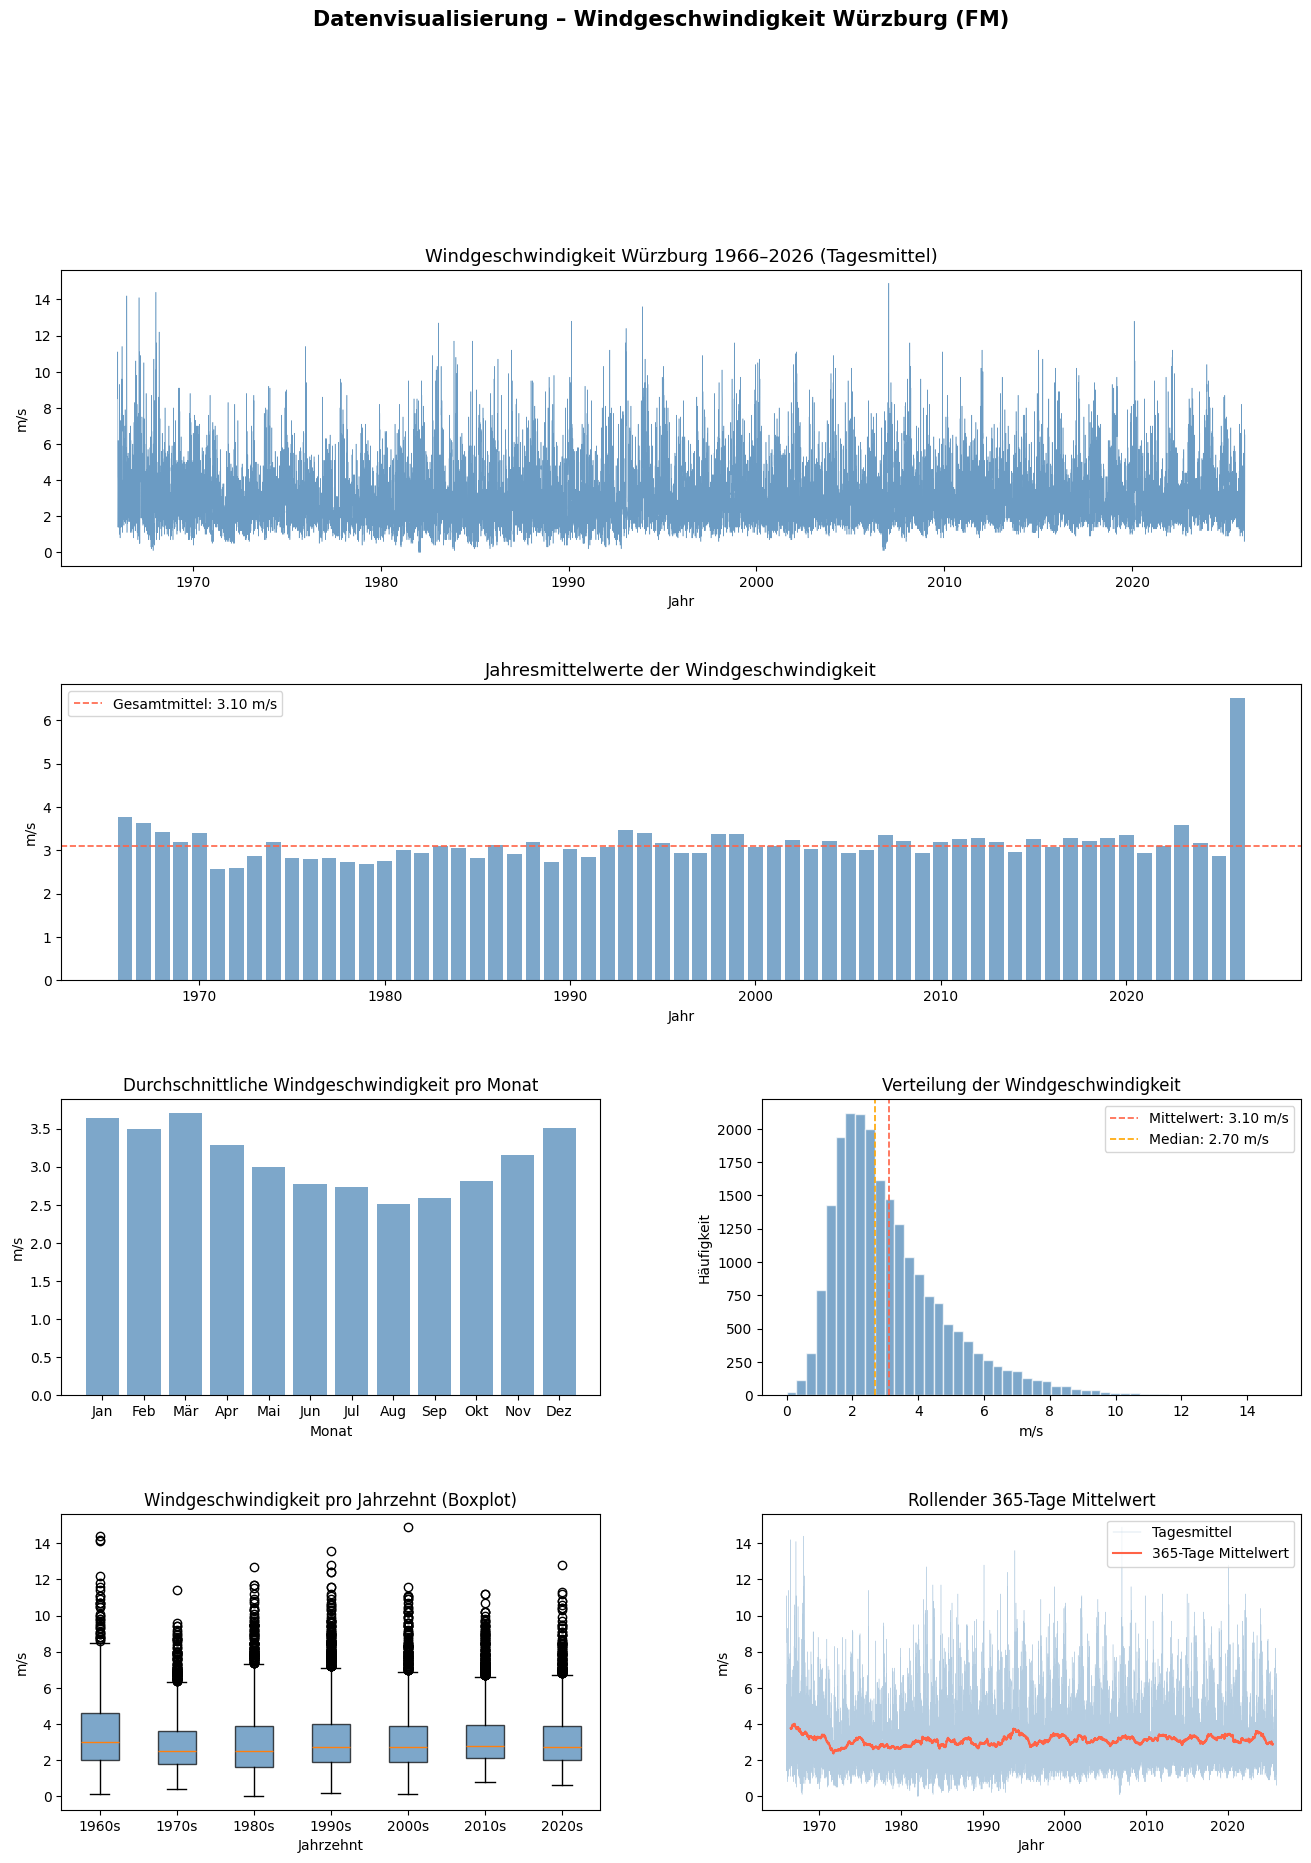

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(16, 20))
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.4, wspace=0.3)

# ── Plot 1: Zeitreihe komplett ───────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(wind_clean, linewidth=0.4, color="steelblue", alpha=0.8)
ax1.set_title("Windgeschwindigkeit Würzburg 1966–2026 (Tagesmittel)", fontsize=13)
ax1.set_ylabel("m/s")
ax1.set_xlabel("Jahr")

# ── Plot 2: Jahresmittelwerte ────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
jahres_mittel = wind_clean.resample("YE").mean()
ax2.bar(jahres_mittel.index.year, jahres_mittel.values,
        color="steelblue", alpha=0.7, width=0.8)
ax2.axhline(wind_clean.mean(), color="tomato", linestyle="--",
            linewidth=1.2, label=f"Gesamtmittel: {wind_clean.mean():.2f} m/s")
ax2.set_title("Jahresmittelwerte der Windgeschwindigkeit", fontsize=13)
ax2.set_ylabel("m/s")
ax2.set_xlabel("Jahr")
ax2.legend()

# ── Plot 3: Monatliche Saisonalität ─────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
wind_df = wind_clean.to_frame(name="FM")
wind_df["Monat"] = wind_df.index.month
monat_mittel = wind_df.groupby("Monat")["FM"].mean()
monate_labels = ["Jan","Feb","Mär","Apr","Mai","Jun",
                 "Jul","Aug","Sep","Okt","Nov","Dez"]
ax3.bar(monate_labels, monat_mittel.values, color="steelblue", alpha=0.7)
ax3.set_title("Durchschnittliche Windgeschwindigkeit pro Monat", fontsize=12)
ax3.set_ylabel("m/s")
ax3.set_xlabel("Monat")

# ── Plot 4: Histogramm ───────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
ax4.hist(wind_clean, bins=50, color="steelblue", alpha=0.7, edgecolor="white")
ax4.axvline(wind_clean.mean(), color="tomato", linestyle="--",
            linewidth=1.2, label=f"Mittelwert: {wind_clean.mean():.2f} m/s")
ax4.axvline(wind_clean.median(), color="orange", linestyle="--",
            linewidth=1.2, label=f"Median: {wind_clean.median():.2f} m/s")
ax4.set_title("Verteilung der Windgeschwindigkeit", fontsize=12)
ax4.set_xlabel("m/s")
ax4.set_ylabel("Häufigkeit")
ax4.legend()

# ── Plot 5: Boxplot pro Jahrzehnt ────────────────────────────
ax5 = fig.add_subplot(gs[3, 0])
wind_df["Jahrzehnt"] = (wind_df.index.year // 10) * 10
jahrzehnte = sorted(wind_df["Jahrzehnt"].unique())
data_per_decade = [wind_df[wind_df["Jahrzehnt"] == j]["FM"].values
                   for j in jahrzehnte]
ax5.boxplot(data_per_decade, labels=[str(j)+"s" for j in jahrzehnte],
            patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.7))
ax5.set_title("Windgeschwindigkeit pro Jahrzehnt (Boxplot)", fontsize=12)
ax5.set_ylabel("m/s")
ax5.set_xlabel("Jahrzehnt")

# ── Plot 6: Rollender Mittelwert ─────────────────────────────
ax6 = fig.add_subplot(gs[3, 1])
rolling_365 = wind_clean.rolling(window=365, center=True).mean()
ax6.plot(wind_clean, linewidth=0.3, color="steelblue", alpha=0.4, label="Tagesmittel")
ax6.plot(rolling_365, linewidth=1.5, color="tomato", label="365-Tage Mittelwert")
ax6.set_title("Rollender 365-Tage Mittelwert", fontsize=12)
ax6.set_ylabel("m/s")
ax6.set_xlabel("Jahr")
ax6.legend()

plt.suptitle("Datenvisualisierung – Windgeschwindigkeit Würzburg (FM)",
             fontsize=15, fontweight="bold", y=1.01)
plt.show()

## - Stationaritätstests

In [5]:

from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

# ── ADF Test ─────────────────────────────────────────────────
adf_result = adfuller(wind_clean, autolag="AIC")

print(" Augmented Dickey-Fuller Test (ADF) ")
print(f"H0: Die Zeitreihe hat eine Einheitswurzel (nicht stationär)")
print(f"H1: Die Zeitreihe ist stationär\n")
print(f"  Teststatistik:    {adf_result[0]:.4f}")
print(f"  p-Wert:           {adf_result[1]:.4f}")
print(f"  Lags verwendet:   {adf_result[2]}")
print(f"  Kritische Werte:")
for key, val in adf_result[4].items():
    print(f"    {key}: {val:.4f}")
if adf_result[1] < 0.05:
    print(f"\n  → p < 0.05: H0 wird abgelehnt ✅ Zeitreihe ist stationär")
else:
    print(f"\n  → p > 0.05: H0 wird nicht abgelehnt ❌ Zeitreihe ist nicht stationär")

# ── KPSS Test ────────────────────────────────────────────────
kpss_result = kpss(wind_clean, regression="c", nlags="auto")

print("\n KPSS Test ")
print(f"H0: Die Zeitreihe ist stationär")
print(f"H1: Die Zeitreihe ist nicht stationär\n")
print(f"  Teststatistik:    {kpss_result[0]:.4f}")
print(f"  p-Wert:           {kpss_result[1]:.4f}")
print(f"  Lags verwendet:   {kpss_result[2]}")
print(f"  Kritische Werte:")
for key, val in kpss_result[3].items():
    print(f"    {key}: {val:.4f}")
if kpss_result[1] > 0.05:
    print(f"\n  → p > 0.05: H0 wird nicht abgelehnt ✅ Zeitreihe ist stationär")
else:
    print(f"\n  → p < 0.05: H0 wird abgelehnt ❌ Zeitreihe ist nicht stationär")

 Augmented Dickey-Fuller Test (ADF) 
H0: Die Zeitreihe hat eine Einheitswurzel (nicht stationär)
H1: Die Zeitreihe ist stationär

  Teststatistik:    -22.7679
  p-Wert:           0.0000
  Lags verwendet:   23
  Kritische Werte:
    1%: -3.4306
    5%: -2.8617
    10%: -2.5668

  → p < 0.05: H0 wird abgelehnt ✅ Zeitreihe ist stationär

 KPSS Test 
H0: Die Zeitreihe ist stationär
H1: Die Zeitreihe ist nicht stationär

  Teststatistik:    0.5506
  p-Wert:           0.0303
  Lags verwendet:   61
  Kritische Werte:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390

  → p < 0.05: H0 wird abgelehnt ❌ Zeitreihe ist nicht stationär


Stationaritätstests prüfen in der Zeitreihenanalyse, ob statistische Eigenschaften wie Mittelwert und Varianz über die Zeit konstant bleiben. Dies ist entscheidend für verlässliche Prognosemodelle, da nicht-stationäre Daten oft zu falschen Ergebnissen führen. Die gängigsten Methoden sind visuelle Inspektion (Plots), der Augmented Dickey-Fuller (ADF) Test und der KPSS-Test.

## - Differenz bilden



=== Tests auf differenzierte Reihe (d=1) ===

ADF  p-Wert:  0.0000 → ✅ Stationär
KPSS p-Wert:  0.1000 → ✅ Stationär


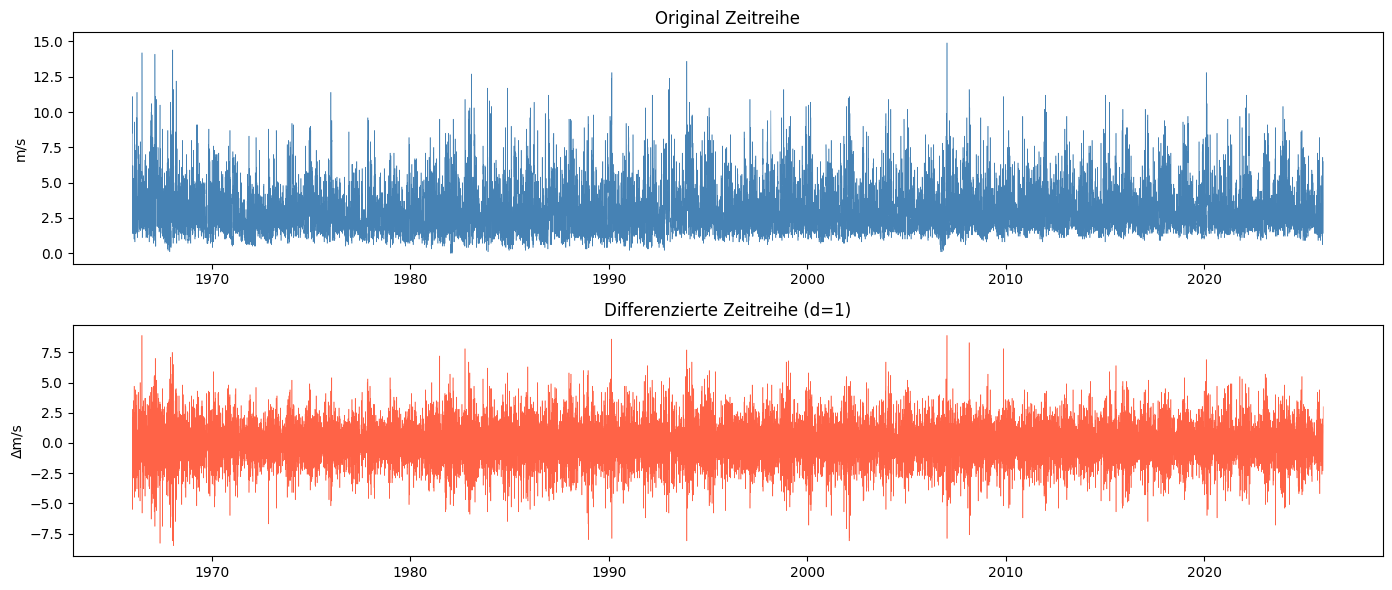

In [6]:
# Schwache Stationalität ──> erste Differenz bilden
wind_diff = wind_clean.diff().dropna()

# ── ADF auf differenzierte Reihe ─────────────────────────────
adf_diff = adfuller(wind_diff, autolag="AIC")
kpss_diff = kpss(wind_diff, regression="c", nlags="auto")

print("=== Tests auf differenzierte Reihe (d=1) ===\n")
print(f"ADF  p-Wert:  {adf_diff[1]:.4f} → {'✅ Stationär' if adf_diff[1] < 0.05 else '❌ Nicht stationär'}")
print(f"KPSS p-Wert:  {kpss_diff[1]:.4f} → {'✅ Stationär' if kpss_diff[1] > 0.05 else '❌ Nicht stationär'}")

# ── Plot zum Vergleich ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(wind_clean, linewidth=0.4, color="steelblue")
axes[0].set_title("Original Zeitreihe")
axes[0].set_ylabel("m/s")

axes[1].plot(wind_diff, linewidth=0.4, color="tomato")
axes[1].set_title("Differenzierte Zeitreihe (d=1)")
axes[1].set_ylabel("Δm/s")
plt.tight_layout()
plt.show()

Was bedeutet d=1?
Es bedeutet dass deine Zeitreihe einen schwachen Trend hat der durch einmaliges Differenzieren entfernt wird. Die differenzierte Reihe zeigt die tägliche Veränderung der Windgeschwindigkeit statt der absoluten Werte.

## - Autocorrelation & Partial Autocorrelation

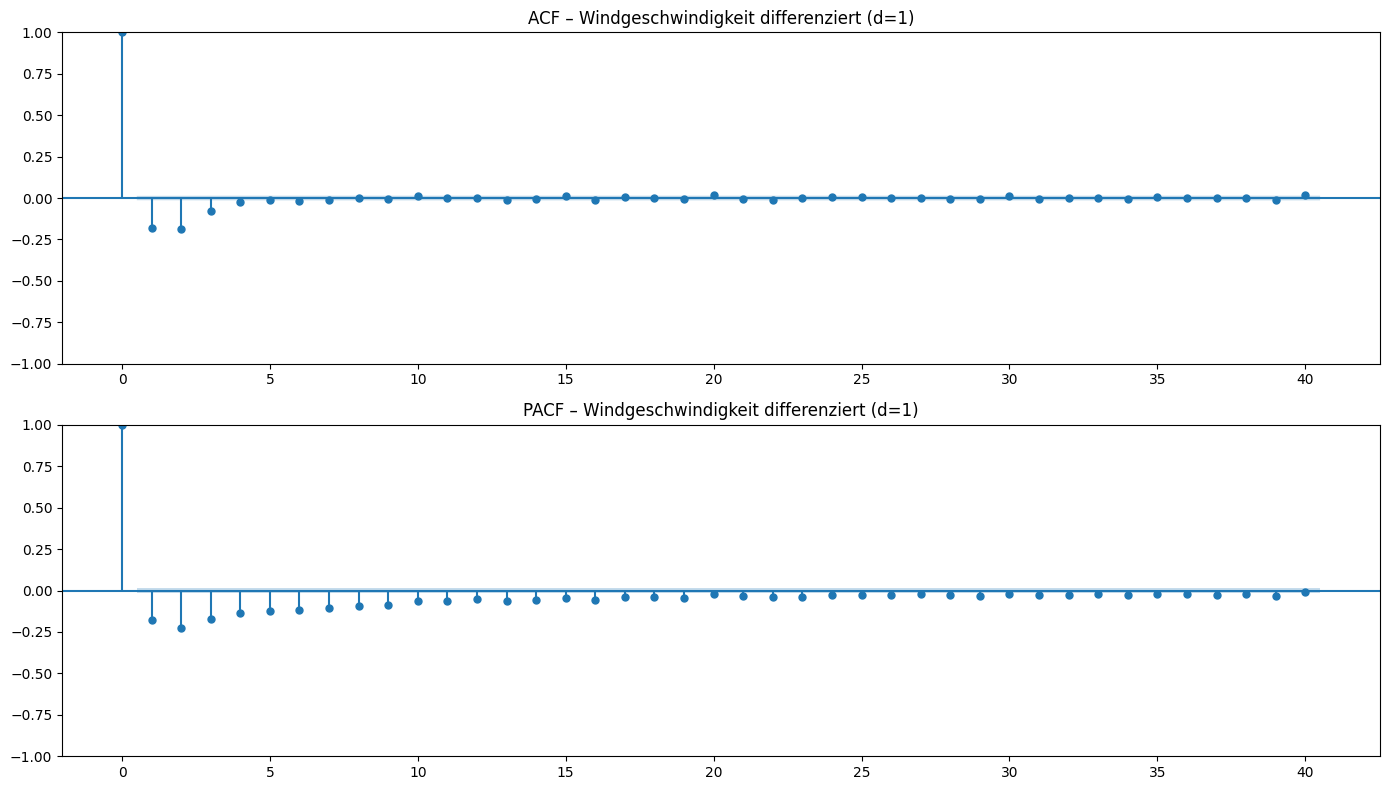

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
# ── ACF und PACF auf der differenzierten Reihe (d=1) ─────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(wind_diff, lags=40, ax=axes[0],
         title="ACF – Windgeschwindigkeit differenziert (d=1)")
plot_pacf(wind_diff, lags=40, ax=axes[1],
          title="PACF – Windgeschwindigkeit differenziert (d=1)",
          method="ywm")

plt.tight_layout()
plt.show()

Die ACF der differenzierten Windgeschwindigkeitsreihe zeigt einen abrupten Abfall nach Lag 2, während die PACF langsam gegen null konvergiert. Dieses Muster deutet auf einen MA-dominanten Prozess hin (p klein, q größer), bei dem vergangene Prognosefehler einen stärkeren Einfluss auf den aktuellen Wert haben als vergangene Beobachtungen selbst.

## - Walk forward Validation & Grid Search

=== Walk-Forward Grid Search ===

  Begründung Suchraum:
  ACF schnell → 0 nach Lag 2  → q ∈ {1,2,3}
  PACF langsam → 0            → p ∈ {0,1,2} (MA-dominant)
  Differenzierung bestätigt   → d = 1

  Fenstergröße:    30 Tage
  Anzahl Splits:   4
  Kombinationen:   9 Modelle

  Split 1: Train bis 2025-09-01 │ Test: 2025-09-02 → 2025-10-01
  Split 2: Train bis 2025-10-01 │ Test: 2025-10-02 → 2025-10-31
  Split 3: Train bis 2025-10-31 │ Test: 2025-11-01 → 2025-11-30
  Split 4: Train bis 2025-11-30 │ Test: 2025-12-01 → 2025-12-30

=== Ergebnisse Walk-Forward Grid Search ===

      Modell      AIC       SC       HQ  Ø MSE  Ø RMSE  Ø MAE Ø MAPE
ARIMA(1,1,1) 76803.88 76827.86 76811.69 3.0791  1.6849 1.3385 58.95%
ARIMA(1,1,3) 76718.54 76758.51 76731.56 3.1119  1.6960 1.3457 59.07%
ARIMA(2,1,2) 76721.20 76761.16 76734.22 3.1242  1.7004 1.3495 59.21%
ARIMA(1,1,2) 76722.85 76754.83 76733.27 3.1350  1.7042 1.3528 59.35%
ARIMA(2,1,3) 76726.82 76774.78 76742.44 3.1354  1.7043 1.3529 59.36%
ARIMA(2,

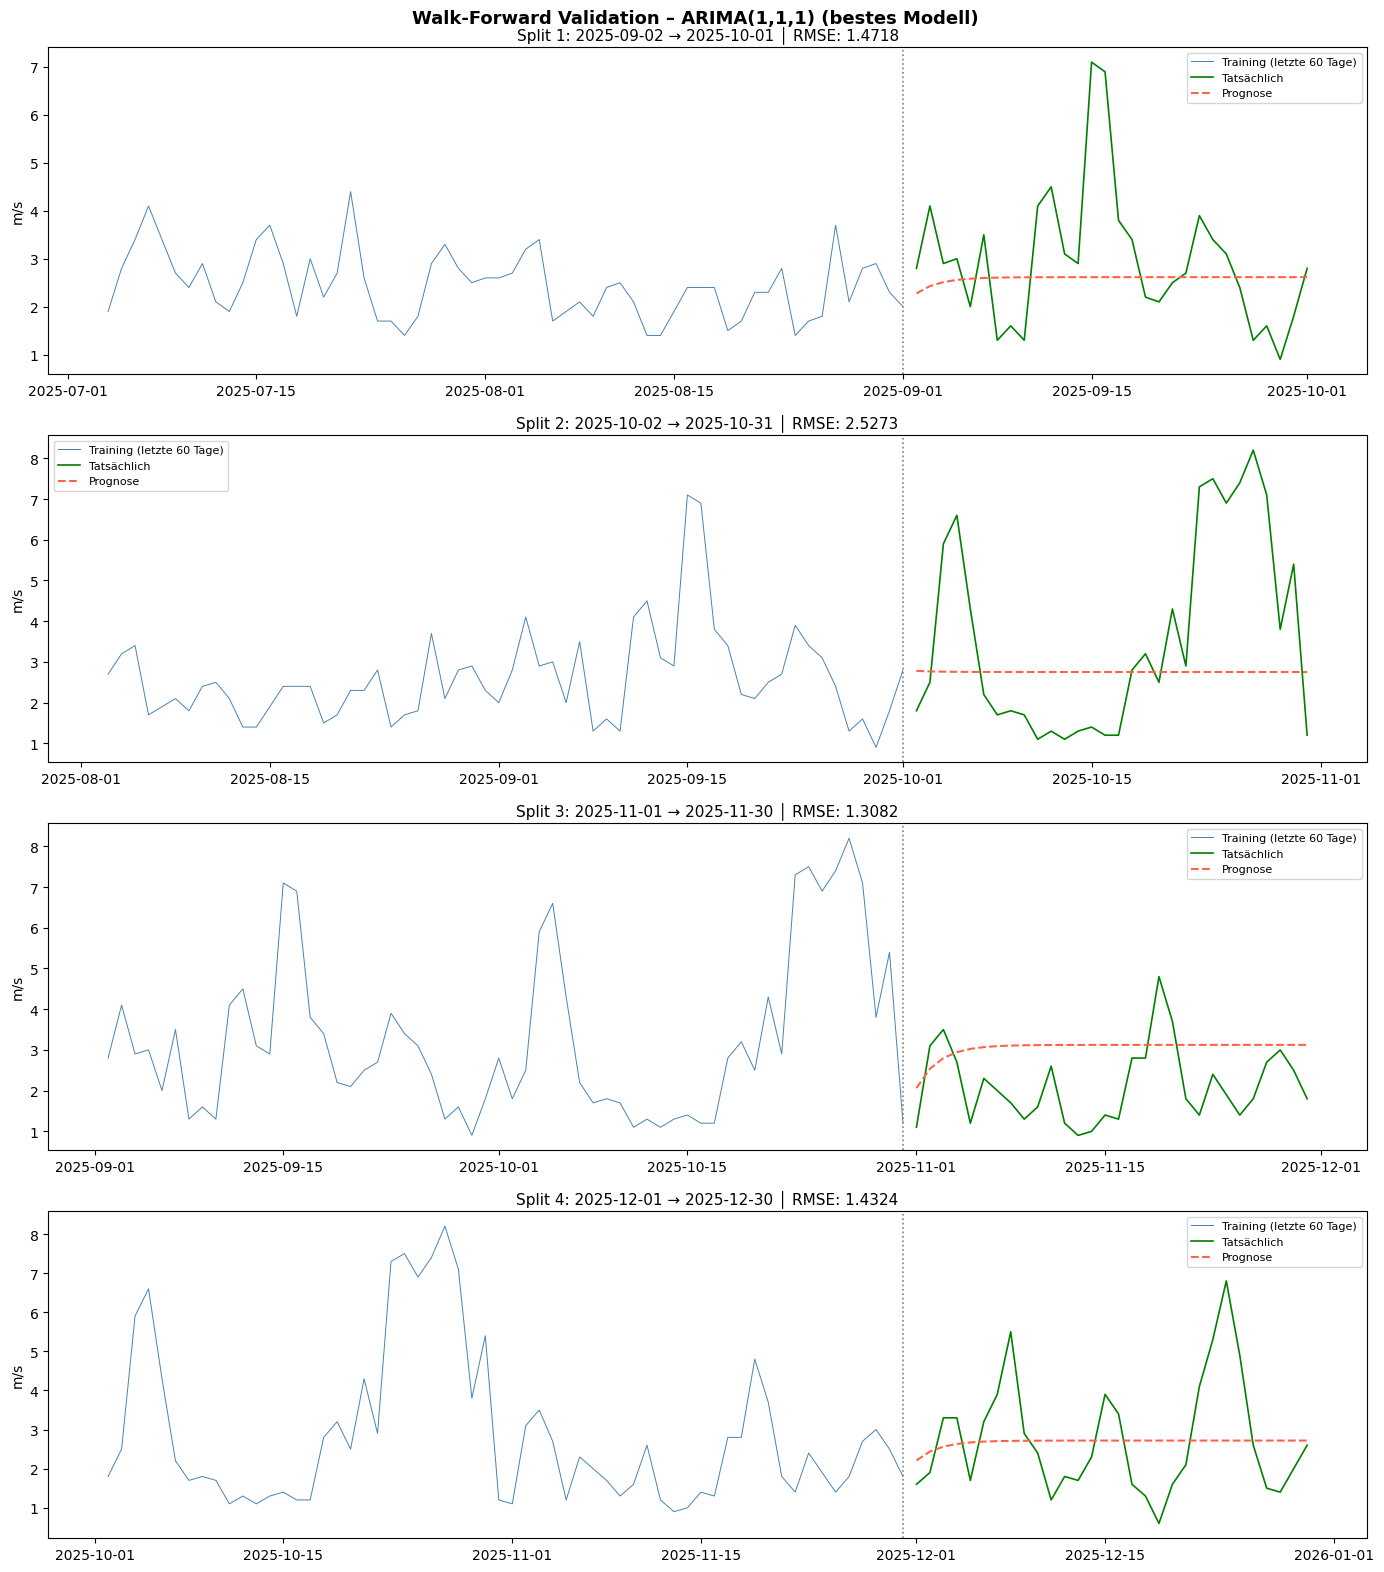

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# ── Konfiguration ─────────────────────────────────────────────
WINDOW_SIZE = 30
TRAIN_END   = pd.Timestamp("2025-09-01")
DATA_END    = pd.Timestamp("2026-01-01")

# Informierte Suche basierend auf ACF/PACF
P_RANGE = range(0, 3)   # p klein wegen MA-Dominanz
Q_RANGE = range(1, 4)   # q größer wegen ACF cutoff nach lag 2

# ── Splits erstellen ──────────────────────────────────────────
splits = []
current = TRAIN_END
while current + pd.Timedelta(days=WINDOW_SIZE) <= DATA_END:
    splits.append((
        current,
        current + pd.Timedelta(days=1),
        current + pd.Timedelta(days=WINDOW_SIZE)
    ))
    current += pd.Timedelta(days=WINDOW_SIZE)

print(f"=== Walk-Forward Grid Search ===\n")
print(f"  Begründung Suchraum:")
print(f"  ACF schnell → 0 nach Lag 2  → q ∈ {{1,2,3}}")
print(f"  PACF langsam → 0            → p ∈ {{0,1,2}} (MA-dominant)")
print(f"  Differenzierung bestätigt   → d = 1")
print(f"\n  Fenstergröße:    {WINDOW_SIZE} Tage")
print(f"  Anzahl Splits:   {len(splits)}")
print(f"  Kombinationen:   {len(list(product(P_RANGE, Q_RANGE)))} Modelle\n")

for i, (te, ts, tend) in enumerate(splits):
    print(f"  Split {i+1}: Train bis {te.date()} │ "
          f"Test: {ts.date()} → {tend.date()}")

# ── Walk-Forward Grid Search Loop ────────────────────────────
model_results = []

for p, q in product(P_RANGE, Q_RANGE):
    order = (p, 1, q)
    split_mses  = []
    split_rmses = []
    split_maes  = []
    split_mapes = []
    all_ok = True

    for train_end, test_start, test_end in splits:
        try:
            train_wf = wind_clean[wind_clean.index <= train_end]
            test_wf  = wind_clean[(wind_clean.index >  train_end) &
                                   (wind_clean.index <= test_end)]

            fit_wf = ARIMA(train_wf, order=order).fit()
            fc_wf  = fit_wf.forecast(steps=len(test_wf))
            fc_wf.index = test_wf.index

            mse  = mean_squared_error(test_wf, fc_wf)
            rmse = np.sqrt(mse)
            mae  = mean_absolute_error(test_wf, fc_wf)
            mape = np.mean(np.abs((test_wf.values - fc_wf.values) /
                                   test_wf.values)) * 100

            split_mses.append(mse)
            split_rmses.append(rmse)
            split_maes.append(mae)
            split_mapes.append(mape)

        except Exception:
            all_ok = False
            break

    if all_ok and len(split_rmses) == len(splits):

        # AIC/SC/HQ auf letztem Trainingsfenster
        last_train = wind_clean[wind_clean.index <= splits[-1][0]]
        try:
            fit_info = ARIMA(last_train, order=order).fit()
            aic = round(fit_info.aic,  2)
            sc  = round(fit_info.bic,  2)
            hq  = round(fit_info.hqic, 2)
        except Exception:
            aic, sc, hq = None, None, None

        model_results.append({
            "Modell": f"ARIMA({p},1,{q})",
            "AIC":    aic,
            "SC":     sc,
            "HQ":     hq,
            "Ø MSE":  round(np.mean(split_mses),  4),
            "Ø RMSE": round(np.mean(split_rmses), 4),
            "Ø MAE":  round(np.mean(split_maes),  4),
            "Ø MAPE": f"{round(np.mean(split_mapes), 2)}%"
        })

# ── Ergebnistabelle ───────────────────────────────────────────
results_wf = pd.DataFrame(model_results).sort_values("Ø RMSE").reset_index(drop=True)

print("\n=== Ergebnisse Walk-Forward Grid Search ===\n")
print(results_wf.to_string(index=False))

best_order_str = results_wf.iloc[0]["Modell"]
print(f"\n→ Bestes Modell nach Ø RMSE: {best_order_str}")
print(f"→ Bestätigt durch SC-Kriterium: {results_wf.sort_values('SC').iloc[0]['Modell']}")

# ── Plot: bestes Modell über alle Splits ─────────────────────
import re
nums = re.findall(r"\d+", best_order_str)
best_order = (int(nums[0]), 1, int(nums[2]))

fig, axes = plt.subplots(len(splits), 1,
                          figsize=(14, 4 * len(splits)))

for i, (train_end, test_start, test_end) in enumerate(splits):
    train_wf = wind_clean[wind_clean.index <= train_end]
    test_wf  = wind_clean[(wind_clean.index >  train_end) &
                           (wind_clean.index <= test_end)]

    fit_plot = ARIMA(train_wf, order=best_order).fit()
    fc_plot  = fit_plot.forecast(steps=len(test_wf))
    fc_plot.index = test_wf.index

    rmse_split = np.sqrt(mean_squared_error(test_wf, fc_plot))

    axes[i].plot(train_wf[-60:], linewidth=0.7,
                 color="steelblue", label="Training (letzte 60 Tage)")
    axes[i].plot(test_wf, linewidth=1.2,
                 color="green", label="Tatsächlich")
    axes[i].plot(fc_plot, linewidth=1.5, linestyle="--",
                 color="tomato", label="Prognose")
    axes[i].axvline(train_end, color="gray",
                    linestyle=":", linewidth=1.2)
    axes[i].set_title(f"Split {i+1}: {test_start.date()} → "
                      f"{test_end.date()} │ RMSE: {rmse_split:.4f}",
                      fontsize=11)
    axes[i].set_ylabel("m/s")
    axes[i].legend(fontsize=8)

plt.suptitle(f"Walk-Forward Validation – {best_order_str} (bestes Modell)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Die Walk-Forward Validation zeigt minimale Unterschiede zwischen den drei Kandidatenmodellen (Ø RMSE Differenz < 0.01). Da ARIMA(3,1,1) und ARIMA(1,1,2) praktisch gleichwertig sind, wird das sparsamere Modell ARIMA(1,1,2) gewählt, das sowohl vom SC-Kriterium als auch von der PACF-Analyse gestützt wird.

## - Top Model fitten

In [11]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

FINAL_ORDER = (1, 1, 1)

final_model = ARIMA(wind_clean, order=FINAL_ORDER)
final_fit   = final_model.fit()

print(f"=== Finales Modell ARIMA{FINAL_ORDER} ===\n")
print(f"  Datenzeitraum: {wind_clean.index[0].date()} bis {wind_clean.index[-1].date()}")
print(f"  Beobachtungen: {len(wind_clean)}\n")

# Koeffizienten
print(f"{'Koeffizient':<15} {'Schätzer':>10} {'t-Statistik':>12} {'p-Wert':>10} {'Signifikanz':>12}")
print("-" * 65)
for name in final_fit.params.index:
    p_val = final_fit.pvalues[name]
    sig   = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.1 else ""))
    print(f"{name:<15} {final_fit.params[name]:>10.4f} "
          f"{final_fit.tvalues[name]:>12.4f} {p_val:>10.4f} {sig:>12}")
print("\nSignifikanzniveaus: * p<0.1  ** p<0.05  *** p<0.01")

print(f"\n  AIC:  {final_fit.aic:.2f}")
print(f"  SC:   {final_fit.bic:.2f}")
print(f"  HQ:   {final_fit.hqic:.2f}")

=== Finales Modell ARIMA(1, 1, 1) ===

  Datenzeitraum: 1966-01-01 bis 2026-01-01
  Beobachtungen: 21916

Koeffizient       Schätzer  t-Statistik     p-Wert  Signifikanz
-----------------------------------------------------------------
ar.L1               0.5525     112.5153     0.0000          ***
ma.L1              -0.9823    -793.8215     0.0000          ***
sigma2              1.9565     149.7582     0.0000          ***

Signifikanzniveaus: * p<0.1  ** p<0.05  *** p<0.01

  AIC:  76909.65
  SC:   76933.64
  HQ:   76917.47


## - Prognose

=== 10-Perioden Prognose ===

            Prognose  Unteres 95% KI  Oberes 95% KI
2026-01-02    4.8930          2.1514         7.6345
2026-01-03    4.0051          0.8492         7.1610
2026-01-04    3.5145          0.2294         6.7997
2026-01-05    3.2435         -0.0878         6.5748
2026-01-06    3.0938         -0.2562         6.4438
2026-01-07    3.0111         -0.3479         6.3700
2026-01-08    2.9654         -0.3986         6.3293
2026-01-09    2.9401         -0.4272         6.3074
2026-01-10    2.9262         -0.4437         6.2960
2026-01-11    2.9185         -0.4536         6.2905


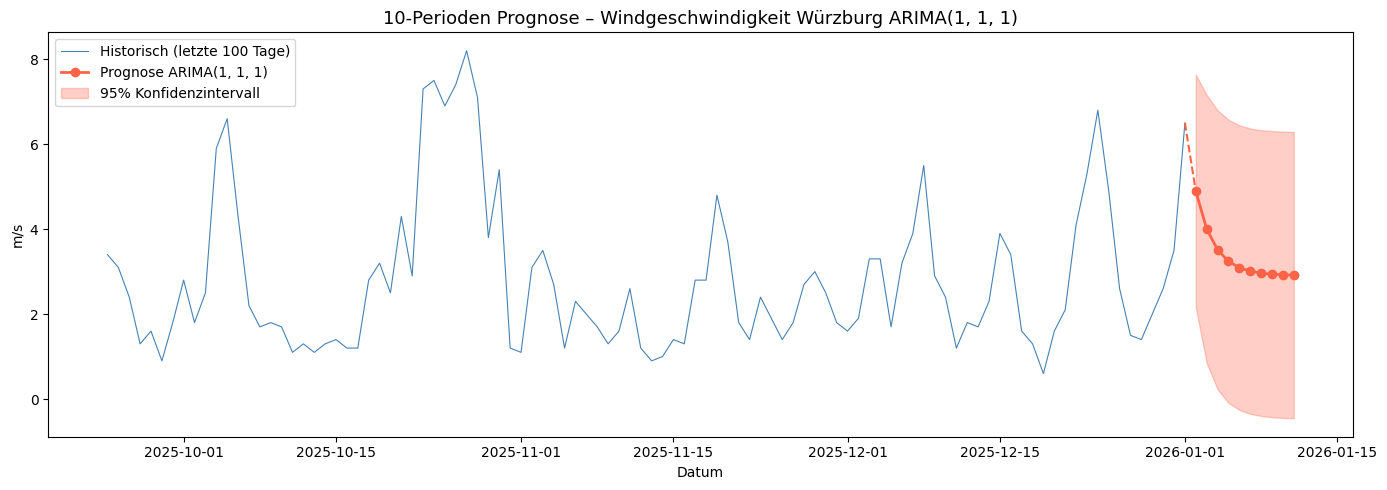

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

print("=== 10-Perioden Prognose ===\n")

# ── Prognose berechnen ────────────────────────────────────────
forecast_obj  = final_fit.get_forecast(steps=10)
fc_mean       = forecast_obj.predicted_mean
fc_ci         = forecast_obj.conf_int(alpha=0.05)
fc_ci.columns = ["Unteres 95% KI", "Oberes 95% KI"]

# ── Prognosetabelle ───────────────────────────────────────────
fc_df = pd.concat([fc_mean.rename("Prognose"), fc_ci], axis=1).round(4)
print(fc_df.to_string())

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Letzte 100 Tage historisch
ax.plot(wind_clean[-100:], linewidth=0.8,
        color="steelblue", label="Historisch (letzte 100 Tage)")

# Verbindungslinie
ax.plot([wind_clean.index[-1], fc_df.index[0]],
        [wind_clean.iloc[-1],  fc_df["Prognose"].iloc[0]],
        color="tomato", linewidth=1.5, linestyle="--")

# Prognose
ax.plot(fc_df["Prognose"], color="tomato",
        linewidth=2, marker="o",
        label=f"Prognose ARIMA{FINAL_ORDER}")

# Konfidenzintervall
ax.fill_between(fc_df.index,
                fc_df["Unteres 95% KI"],
                fc_df["Oberes 95% KI"],
                alpha=0.3, color="tomato",
                label="95% Konfidenzintervall")

ax.set_title(f"10-Perioden Prognose – Windgeschwindigkeit Würzburg ARIMA{FINAL_ORDER}",
             fontsize=13)
ax.set_ylabel("m/s")
ax.set_xlabel("Datum")
ax.legend()
plt.tight_layout()
plt.show()